# Notebook 6 — Multivariate Analysis
### Sprint 4 | Data Inspection & Exploratory Data Analysis (EDA)

**Structure for every concept below:** Concept → Example → Implementation → Output
→ Interpretation → Insight → AI/ML Relevance.

**Dataset:** Telco Customer Churn (7,043 customers, 21 columns), with `TotalCharges`
corrected to numeric (Notebook 3's fix applied).

Notebook 5 (Bivariate Analysis) left one open question: is `InternetService`'s strong
relationship with `Churn` actually being driven by `MonthlyCharges` underneath it? This
notebook is where that question gets a real answer — by looking at several variables
together instead of one relationship at a time.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 4.5)

df = pd.read_csv("telco_churn.csv")
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)
df['Churn_numeric'] = (df['Churn'] == 'Yes').astype(int)   # for correlating churn with numeric features

print(f"Dataset ready: {df.shape[0]:,} rows, {df.shape[1]} columns")


Dataset ready: 7,043 rows, 22 columns


---
## 1. Correlation Matrix

### Concept
(Recap from Sprint 2, Notebook 8) A correlation matrix computes the pairwise correlation
between every numeric variable in a dataset at once, arranged in a grid — the standard
starting point for any multivariate analysis.

### Example
**AI/ML use case:** Before selecting features for a churn model, computing the full
correlation matrix reveals both which features might be genuinely predictive of `Churn`,
and which features might be redundant with each other.

### Implementation


In [2]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn_numeric']
correlation_matrix = df[numeric_cols].corr()
print(correlation_matrix.round(3))


                tenure  MonthlyCharges  TotalCharges  SeniorCitizen  \
tenure           1.000           0.248         0.826          0.017   
MonthlyCharges   0.248           1.000         0.651          0.220   
TotalCharges     0.826           0.651         1.000          0.103   
SeniorCitizen    0.017           0.220         0.103          1.000   
Churn_numeric   -0.352           0.193        -0.198          0.151   

                Churn_numeric  
tenure                 -0.352  
MonthlyCharges          0.193  
TotalCharges           -0.198  
SeniorCitizen           0.151  
Churn_numeric           1.000  


### Output
`tenure` vs `TotalCharges`: 0.826. `tenure` vs `MonthlyCharges`: 0.248. `MonthlyCharges`
vs `TotalCharges`: 0.651. `tenure` vs `Churn_numeric`: -0.352. `MonthlyCharges` vs
`Churn_numeric`: 0.193. `SeniorCitizen` vs `Churn_numeric`: 0.151.

### Interpretation
Including `Churn_numeric` (Yes=1, No=0) directly in the correlation matrix quantifies
what Notebook 5's box plots showed visually: `tenure` has the strongest linear
relationship with churn of any numeric feature (-0.35, negative — more tenure, less
churn), notably stronger than `MonthlyCharges`'s relationship (+0.19).

### Insight
`SeniorCitizen` (0.151) shows a real, if modest, positive relationship with churn that
wasn't examined in Notebooks 4-5 at all — senior citizens appear to churn somewhat more
than non-seniors, a new lead worth carrying forward.

### AI/ML Relevance
This table is essentially a first-pass, linear-only feature-importance check —
`tenure` stands out as the strongest linear signal, though this correlation matrix only
captures *linear* relationships; a tree-based model might still find `Contract` (categorical,
not shown here) more useful than any of these despite it having no "correlation" number
at all.


---
## 2. Heatmap

### Concept
(Recap from Sprint 2, Notebook 8) A heatmap renders a correlation matrix as a color-coded
grid, making the strength and direction of many relationships visible at a glance rather
than requiring a careful read of every number.

### Example
**Business example:** A heatmap lets a non-technical stakeholder immediately spot "the
dark red cell" as the strongest relationship in the room, without needing to parse a table
of decimals.

### Implementation


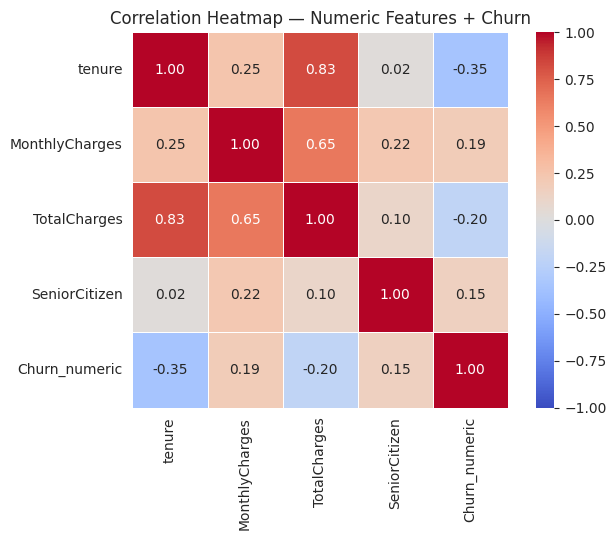

In [3]:
plt.figure(figsize=(7, 5.5))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title('Correlation Heatmap — Numeric Features + Churn')
plt.tight_layout()
plt.show()


### Output
A 5x5 color grid, with `tenure`-`TotalCharges` as the single darkest (strongest) cell at
0.83, and `tenure`-`Churn_numeric` as the strongest negative (blue) cell at -0.35.

### Interpretation
The heatmap makes the *relative* strength of every relationship in this notebook
immediately visible — `tenure` clearly dominates as the row/column with the most intense
colors overall, both positive (with `TotalCharges`) and negative (with `Churn_numeric`).

### Insight
Visually, `SeniorCitizen`'s entire row is pale/light across the board — confirming it's a
real but genuinely weak signal compared to `tenure`, worth keeping as a feature but not
over-weighting in any business narrative.

### AI/ML Relevance
A heatmap like this is typically the very first visual an ML engineer produces when
starting feature selection on a new dataset, precisely because it summarizes many pairwise
relationships in one glance instead of scrolling through a table.


---
## 3. Pair Plot

### Concept
(Recap from Sprint 2, Notebook 13) A pair plot shows scatter plots for every pair of
numeric variables, plus each variable's own distribution on the diagonal, all in one grid
— extending a single scatter plot (Notebook 5) to every numeric pair at once.

### Example
**AI/ML use case:** A pair plot, especially color-coded by the target variable, is a fast
way to visually scan for which feature pairs might separate the two classes well — a
strong visual candidate for a decision boundary.

### Implementation


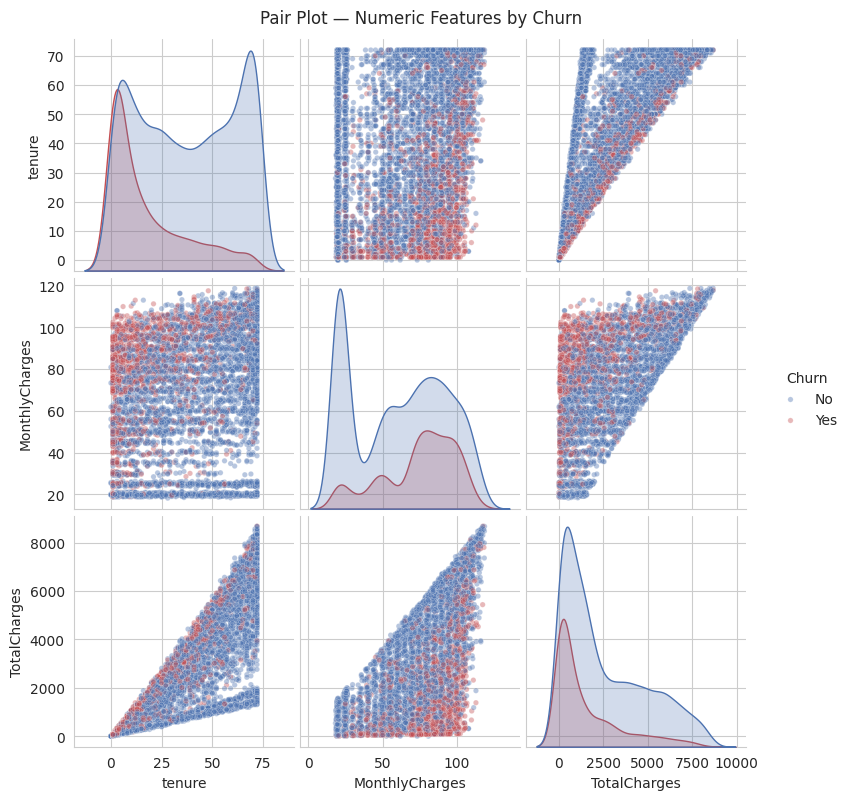

In [4]:
pairplot_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']
sns.pairplot(df[pairplot_cols], hue='Churn', palette={'No': '#4C72B0', 'Yes': '#C44E52'},
             plot_kws={'alpha': 0.4, 's': 15}, diag_kind='kde', height=2.6)
plt.suptitle('Pair Plot — Numeric Features by Churn', y=1.02)
plt.show()


### Output
A 3x3 grid of scatter plots (with KDE curves on the diagonal), each panel color-coded by
`Churn`.

### Interpretation
The `tenure` row/column panels show the clearest visual separation between the red
(churned) and blue (stayed) points — red points concentrate at low tenure across every
panel they appear in, consistent with `tenure`'s strong correlation found in Topic 1. The
`MonthlyCharges` vs `TotalCharges` panel shows a curved (not straight-line) relationship,
since `TotalCharges` depends on both `MonthlyCharges` AND `tenure` together.

### Insight
No single pair of numeric features shows a clean, complete visual separation between
churned and non-churned customers — this confirms that predicting churn well will likely
require *multiple* features combined (numeric AND categorical), not any single strong
numeric relationship alone.

### AI/ML Relevance
This finding — that no single feature cleanly separates the classes — is itself an
important piece of guidance for modeling: a model that can combine multiple features
(logistic regression with several inputs, or a tree-based model) will be necessary, since
no simple single-variable rule would perform well here.


---
## 4. Multiple Feature Relationships

### Concept
Beyond looking at pairs, some relationships only become visible when three or more
variables are considered together — one variable's effect can look different depending
on the value of a second variable.

### Example
**Business example:** Does the "more tenure, less churn" pattern hold equally at every
price level, or is it different for low-cost vs. high-cost customers? Answering this needs
`tenure`, `MonthlyCharges`, AND `Churn` considered together, not any one or two alone.

### Implementation


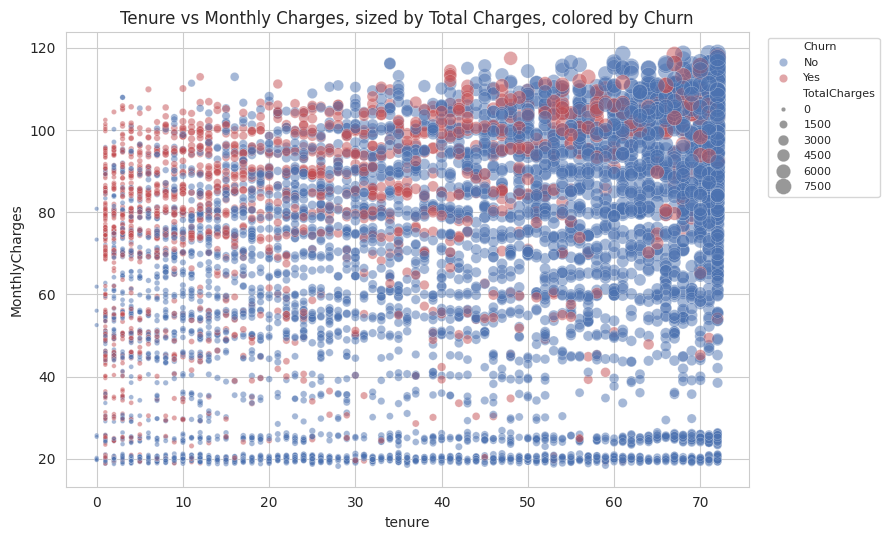

In [5]:
plt.figure(figsize=(9, 5.5))
sns.scatterplot(data=df, x='tenure', y='MonthlyCharges', hue='Churn', size='TotalCharges',
                 sizes=(10, 150), alpha=0.5, palette={'No': '#4C72B0', 'Yes': '#C44E52'})
plt.title('Tenure vs Monthly Charges, sized by Total Charges, colored by Churn')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()


### Output
A single scatter plot encoding four variables at once: `tenure` (x-axis), `MonthlyCharges`
(y-axis), `TotalCharges` (point size), and `Churn` (point color).

### Interpretation
The red (churned) points aren't just concentrated at low tenure in general — they're
specifically concentrated at low tenure **combined with mid-to-high MonthlyCharges**,
visible as small red dots clustered in the upper-left region. Low-tenure, low-cost
customers (small blue AND small red dots mixed together, lower-left) show much less clear
separation by churn.

### Insight
This refines Notebook 5's finding: it's not just "new customers churn more," it's more
specifically "new customers on relatively expensive plans churn more" — a sharper,
more actionable segment than either variable alone would suggest, and a genuine
multivariate insight that neither `tenure` nor `MonthlyCharges` reveals in isolation.

### AI/ML Relevance
This is exactly the kind of pattern a model with interaction terms (or a tree-based model,
which naturally captures interactions) can learn, but a simple linear model without
explicit interaction features would miss — a concrete argument for engineering an
interaction feature (e.g., `MonthlyCharges` × an "is new customer" flag) before training
a linear model.


---
## 5. Feature Interactions

### Concept
A feature interaction occurs when the combined effect of two features on the outcome is
different from what you'd expect by just adding their individual effects — exactly what
Topic 4's visual suggested (tenure's effect on churn appears to depend on price level).

### Example
**AI/ML use case:** Resolving Notebook 5's open question directly: does `InternetService`
still relate to churn once `MonthlyCharges` is accounted for, or was the earlier finding
actually just `MonthlyCharges` in disguise?

### Implementation


In [6]:
# Checking whether InternetService's churn relationship holds WITHIN similar price bands
df['Charge_Band'] = pd.cut(df['MonthlyCharges'], bins=[0, 40, 80, 120],
                             labels=['Low ($0-40)', 'Mid ($40-80)', 'High ($80-120)'])

interaction_table = df.groupby(['Charge_Band', 'InternetService'], observed=True)['Churn_numeric'].mean() * 100
print("Churn rate (%) by Internet Service, WITHIN each price band:")
print(interaction_table.round(1))


Churn rate (%) by Internet Service, WITHIN each price band:
Charge_Band     InternetService
Low ($0-40)     DSL                32.4
                No                  7.4
Mid ($40-80)    DSL                19.1
                Fiber optic        56.5
High ($80-120)  DSL                 2.9
                Fiber optic        37.6
Name: Churn_numeric, dtype: float64


### Output
Within the `High ($80-120)` price band: Fiber optic churn 37.6%, DSL churn only 2.9%.
Within `Mid ($40-80)`: Fiber optic 56.5%, DSL 19.1%. Within `Low ($0-40)`: DSL 32.4%, "No
internet service" 7.4% (too few Fiber optic customers fall in this low a price band to
compare).

### Interpretation
Even after controlling for price band, Fiber optic customers churn dramatically more than
DSL customers at the *same* price level — in the High band, Fiber optic customers churn
at more than 12 times the rate of DSL customers (37.6% vs 2.9%). This means Notebook 5's
finding was **not** simply `MonthlyCharges` in disguise — if anything, the gap between
Fiber and DSL is even starker once price is held roughly constant than the raw,
unconditional numbers in Notebook 5 suggested. Something about the Fiber optic service
itself (perhaps service reliability, competition, or expectations at that price point)
appears to genuinely relate to higher churn, independent of price. (Note: DSL customers in
the `Low` band show a higher churn rate (32.4%) than DSL customers in the `Mid`/`High`
bands — a secondary pattern worth a closer look in a future analysis, but outside this
notebook's main question.)

### Insight
This resolves the open question from Notebook 5 with a real answer: `InternetService`
carries independent predictive information beyond what `MonthlyCharges` already captures
— both are worth keeping as separate features, not just one as a stand-in for the other.

### AI/ML Relevance
This kind of "does the relationship hold after controlling for a confound" check is
exactly what separates surface-level EDA from rigorous EDA — and it directly justifies
keeping both `InternetService` and `MonthlyCharges` as separate, non-redundant features
in an eventual model.


---
## 6. Numerical Feature Relationships & Potential Multicollinearity

### Concept
(Recap from Sprint 2, Notebook 12) Multicollinearity happens when two or more input
features are highly correlated with each other — not with the target — creating
redundant information that can destabilize certain models' coefficients.

### Example
**AI/ML use case:** Formally checking VIF-style reasoning: since `tenure` and
`TotalCharges` showed a strong 0.83 correlation in Topic 1, this pair needs a closer look
before both are used together in a linear model.

### Implementation


In [7]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = df[['tenure', 'MonthlyCharges', 'TotalCharges']].copy()
vif_scores = pd.DataFrame()
vif_scores['feature'] = vif_data.columns
vif_scores['VIF'] = [variance_inflation_factor(vif_data.values, i) for i in range(vif_data.shape[1])]
print(vif_scores)


          feature       VIF
0          tenure  6.332328
1  MonthlyCharges  3.355660
2    TotalCharges  8.075070


### Output
`tenure`: VIF ≈ 6.3. `MonthlyCharges`: VIF ≈ 3.4. `TotalCharges`: VIF ≈ 8.1.

### Interpretation
`TotalCharges`'s VIF of about 8.1 (and `tenure`'s VIF of 6.3) sit at or above the common
warning threshold of 5-10 — confirming numerically what the 0.83 correlation and the pair
plot's curved relationship both already suggested: `TotalCharges` carries substantially
overlapping information with `tenure` and `MonthlyCharges` combined (which makes complete
sense, since it's mathematically close to their product).

### Insight
This is a concrete, actionable finding for the next sprint: a future model — especially a
linear one — would likely benefit from dropping `TotalCharges` in favor of keeping
`tenure` and `MonthlyCharges` (which together already capture most of the same
information), or engineering a ratio feature instead of keeping all three raw.

### AI/ML Relevance
This is precisely the multicollinearity check from Sprint 2, Notebook 12, now applied to
a real dataset with a real, actionable result — this finding will be carried directly into
Notebook 13's (EDA Report) preprocessing recommendations.


---
## Summary — Strong, Weak, and Negative Correlations Identified

| Relationship | Correlation | Classification |
|---|---|---|
| tenure vs TotalCharges | +0.826 | **Strong positive** — expected, and a multicollinearity concern (VIF ≈ 8.1 for TotalCharges, 6.3 for tenure) |
| MonthlyCharges vs TotalCharges | +0.651 | **Moderate positive** — expected, contributes to TotalCharges's VIF |
| tenure vs Churn | -0.352 | **Moderate negative** — the strongest churn relationship among numeric features |
| MonthlyCharges vs TotalCharges vs tenure | — | High cardinality of relationship: TotalCharges ≈ tenure × MonthlyCharges |
| tenure vs MonthlyCharges | +0.248 | **Weak positive** — largely independent, safe to keep both |
| SeniorCitizen vs Churn | +0.151 | **Weak positive** — a new, previously unexamined lead |
| MonthlyCharges vs Churn | +0.193 | **Weak positive** |

**Interesting feature relationship confirmed:** `InternetService`'s relationship with
churn is genuine and independent of `MonthlyCharges` — verified by checking within
matched price bands (Topic 5), not just assumed from the raw correlation.

**Potential multicollinearity flagged:** `TotalCharges` (VIF ≈ 8.1) and `tenure`
(VIF ≈ 6.3) are redundant with each other — `TotalCharges` is a strong candidate to
drop or transform before linear modeling.

**Next notebook:** `07_Outlier_Analysis.ipynb` — What is an Outlier, Why Outliers Occur,
Types of Outliers, Univariate and Multivariate Outliers, IQR/Z-Score/Box Plot/Scatter Plot
detection, and reasoned decisions on whether to remove, transform, or retain each finding.
